In [ ]:
%pip install torch torchvision torchaudio --upgrade
%pip install scikit-learn joblib matplotlib

In [8]:
import os
import glob
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Chemin vers le dossier sequences (raw string Windows)
SEQ_PATH = r"C:\Users\Maten\Documents\projettellorosdataset\sequences"

# Hyperparams
BATCH_SIZE = 64
LR = 1e-3
EPOCHS = 100
HIDDEN_SIZE = 128
NUM_LAYERS = 2
DROPOUT = 0.1
PATIENCE = 8  # early stopping patience on val loss

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cpu


In [9]:
# Cherche tous les .npz dans le dossier
npz_files = glob.glob(os.path.join(SEQ_PATH, "*.npz"))
if not npz_files:
    raise FileNotFoundError(f"Aucun fichier .npz trouvé dans {os.path.abspath(SEQ_PATH)}")

print(f"{len(npz_files)} fichiers .npz trouvés")

list_Xs = []
list_Xc = []
list_Y = []

for f in npz_files:
    data = np.load(f, allow_pickle=True)
    # Cherche les clés usuelles
    # On suppose X_state, X_cmd, Y_next existent. Sinon on essaye d'autres noms.
    if 'X_state' in data and 'X_cmd' in data and 'Y_next' in data:
        Xs = data['X_state']    # shape (N, seq_len, n_state)
        Xc = data['X_cmd']      # shape (N, seq_len, n_cmd)
        Y = data['Y_next']      # shape (N, n_state_next)
    elif 'X' in data and 'Y' in data:
        # format alternatif
        X_all = data['X']       # maybe (N, seq_len, features)
        # assumption: first n_state are states and remaining are cmds (not guaranteed)
        raise ValueError(f"Fichier {os.path.basename(f)} a format inattendu (keys X/Y). Editez le loader si besoin.")
    else:
        raise ValueError(f"Fichier {os.path.basename(f)} n'a pas les clés attendues. Clés : {list(data.keys())}")

    # Vérifs formes cohérentes
    assert Xs.shape[0] == Xc.shape[0] == Y.shape[0], f"Shapes mismatch in {f}"
    list_Xs.append(Xs)
    list_Xc.append(Xc)
    list_Y.append(Y)

# Concaténation
X_state = np.concatenate(list_Xs, axis=0)   # (N_total, seq_len, n_state)
X_cmd = np.concatenate(list_Xc, axis=0)     # (N_total, seq_len, n_cmd)
Y_next = np.concatenate(list_Y, axis=0)     # (N_total, n_state_next)

print("X_state:", X_state.shape)
print("X_cmd  :", X_cmd.shape)
print("Y_next :", Y_next.shape)

# Fusionner state+cmd en entrée unique [seq_len, feat]
X = np.concatenate([X_state, X_cmd], axis=2)  # (N, seq_len, n_state+n_cmd)
print("X fused shape (N, seq_len, feat):", X.shape)


9 fichiers .npz trouvés
X_state: (129568, 20, 9)
X_cmd  : (129568, 20, 4)
Y_next : (129568, 9)
X fused shape (N, seq_len, feat): (129568, 20, 13)


In [10]:
# 80% train, 10% val, 10% test (approx)
X_train_val, X_test, Y_train_val, Y_test = train_test_split(
    X, Y_next, test_size=0.1, random_state=42, shuffle=True
)
X_train, X_val, Y_train, Y_val = train_test_split(
    X_train_val, Y_train_val, test_size=0.1111111, random_state=42, shuffle=True
)  # 0.1111*0.9 ≈ 0.1 => val ≈ 10%

print("Train:", X_train.shape, Y_train.shape)
print("Val  :", X_val.shape, Y_val.shape)
print("Test :", X_test.shape, Y_test.shape)

# Fit scalers on TRAIN only.
# For sequences, on input we reshape (N*seq_len, feat)
N_train, seq_len, feat_in = X_train.shape
scaler_X = StandardScaler()
scaler_X.fit(X_train.reshape(-1, feat_in))

# For output (Y) shape (N, out_dim)
scaler_Y = StandardScaler()
scaler_Y.fit(Y_train)

# Apply transforms
def scale_X(x, scaler):
    N, L, F = x.shape
    x2 = x.reshape(-1, F)
    x2s = scaler.transform(x2)
    return x2s.reshape(N, L, F)

X_train_s = scale_X(X_train, scaler_X)
X_val_s   = scale_X(X_val, scaler_X)
X_test_s  = scale_X(X_test, scaler_X)

Y_train_s = scaler_Y.transform(Y_train)
Y_val_s   = scaler_Y.transform(Y_val)
Y_test_s  = scaler_Y.transform(Y_test)

print("Scaling done. Example X_train_s mean/std:", X_train_s.mean(), X_train_s.std())


Train: (103654, 20, 13) (103654, 9)
Val  : (12957, 20, 13) (12957, 9)
Test : (12957, 20, 13) (12957, 9)
Scaling done. Example X_train_s mean/std: 2.6384361e-09 1.0000001


In [11]:
class SequenceDataset(Dataset):
    def __init__(self, X, Y):
        # expects numpy arrays: X -> (N, seq_len, feat), Y -> (N, out_dim)
        self.X = torch.from_numpy(X).float()
        self.Y = torch.from_numpy(Y).float()
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, idx):
        # return (seq_len, feat), (out_dim)
        return self.X[idx], self.Y[idx]

train_ds = SequenceDataset(X_train_s, Y_train_s)
val_ds   = SequenceDataset(X_val_s, Y_val_s)
test_ds  = SequenceDataset(X_test_s, Y_test_s)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print("Dataloaders ready. batches:", len(train_loader), len(val_loader), len(test_loader))


Dataloaders ready. batches: 1620 203 203


In [12]:
class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.1, output_size=None):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers>1 else 0.0,
            bidirectional=False
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, hidden_size//2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size//2, output_size)
        )
    def forward(self, x):
        # x: (batch, seq_len, input_size)
        out, (h_n, c_n) = self.lstm(x)  # out: (batch, seq_len, hidden)
        # take last hidden state of last layer
        last_h = h_n[-1]  # (batch, hidden_size)
        y = self.fc(last_h)
        return y

# Create model
input_size = feat_in
output_size = Y_train_s.shape[1]
model = LSTMRegressor(input_size, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS, dropout=DROPOUT, output_size=output_size)
model = model.to(DEVICE)
print(model)


LSTMRegressor(
  (lstm): LSTM(13, 128, num_layers=2, batch_first=True, dropout=0.1)
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=9, bias=True)
  )
)


In [13]:
opt = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

best_val_loss = np.inf
best_state = None
train_losses = []
val_losses = []
no_improve = 0

for epoch in range(1, EPOCHS+1):
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        opt.zero_grad()
        ypred = model(xb)
        loss = criterion(ypred, yb)
        loss.backward()
        opt.step()
        running_loss += loss.item() * xb.size(0)
    train_epoch_loss = running_loss / len(train_ds)
    
    # validation
    model.eval()
    val_running = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            ypred = model(xb)
            loss = criterion(ypred, yb)
            val_running += loss.item() * xb.size(0)
    val_epoch_loss = val_running / len(val_ds)
    
    train_losses.append(train_epoch_loss)
    val_losses.append(val_epoch_loss)
    
    print(f"Epoch {epoch:03d} | Train Loss: {train_epoch_loss:.6e} | Val Loss: {val_epoch_loss:.6e}")
    
    # Early stopping & save best
    if val_epoch_loss < best_val_loss - 1e-9:
        best_val_loss = val_epoch_loss
        best_state = model.state_dict()
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"Early stopping after {epoch} epochs.")
            break

# load best
if best_state is not None:
    model.load_state_dict(best_state)
    print("Model loaded with best validation weights.")


Epoch 001 | Train Loss: 6.998504e-02 | Val Loss: 1.780953e-02
Epoch 002 | Train Loss: 4.256981e-02 | Val Loss: 1.594497e-02
Epoch 003 | Train Loss: 4.074202e-02 | Val Loss: 1.697328e-02
Epoch 004 | Train Loss: 3.932450e-02 | Val Loss: 1.788754e-02
Epoch 005 | Train Loss: 3.807493e-02 | Val Loss: 1.881418e-02
Epoch 006 | Train Loss: 3.749725e-02 | Val Loss: 2.167728e-02
Epoch 007 | Train Loss: 3.685198e-02 | Val Loss: 2.375310e-02
Epoch 008 | Train Loss: 3.645764e-02 | Val Loss: 2.668855e-02
Epoch 009 | Train Loss: 3.543041e-02 | Val Loss: 3.123637e-02
Epoch 010 | Train Loss: 3.464922e-02 | Val Loss: 3.566496e-02
Early stopping after 10 epochs.
Model loaded with best validation weights.


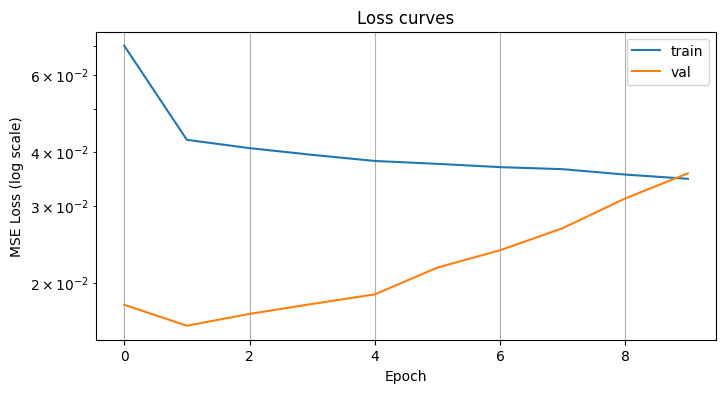

In [14]:
plt.figure(figsize=(8,4))
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss (log scale)')
plt.legend()
plt.title('Loss curves')
plt.grid(True)
plt.show()


In [15]:
model.eval()
preds = []
trues = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        ypred = model(xb)
        preds.append(ypred.cpu().numpy())
        trues.append(yb.cpu().numpy())

preds = np.concatenate(preds, axis=0)
trues = np.concatenate(trues, axis=0)

# Dé-normaliser
preds_phys = scaler_Y.inverse_transform(preds)
trues_phys = scaler_Y.inverse_transform(trues)

rmse_global = np.sqrt(mean_squared_error(trues_phys, preds_phys))
print(f"RMSE global (physique) : {rmse_global:.6f}")

# RMSE par variable
out_dim = preds_phys.shape[1]
for i in range(out_dim):
    rmse_i = np.sqrt(mean_squared_error(trues_phys[:, i], preds_phys[:, i]))
    print(f"Var {i:02d} RMSE : {rmse_i:.6f}")


RMSE global (physique) : 0.250600
Var 00 RMSE : 0.468556
Var 01 RMSE : 0.450263
Var 02 RMSE : 0.329458
Var 03 RMSE : 0.000052
Var 04 RMSE : 0.000171
Var 05 RMSE : 0.178970
Var 06 RMSE : 0.031699
Var 07 RMSE : 0.034462
Var 08 RMSE : 0.012645


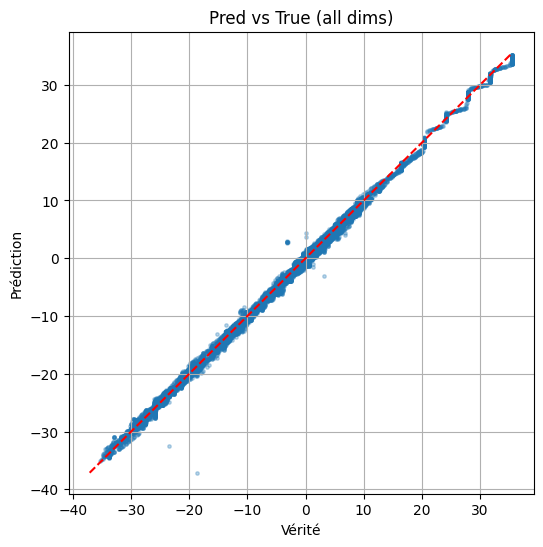

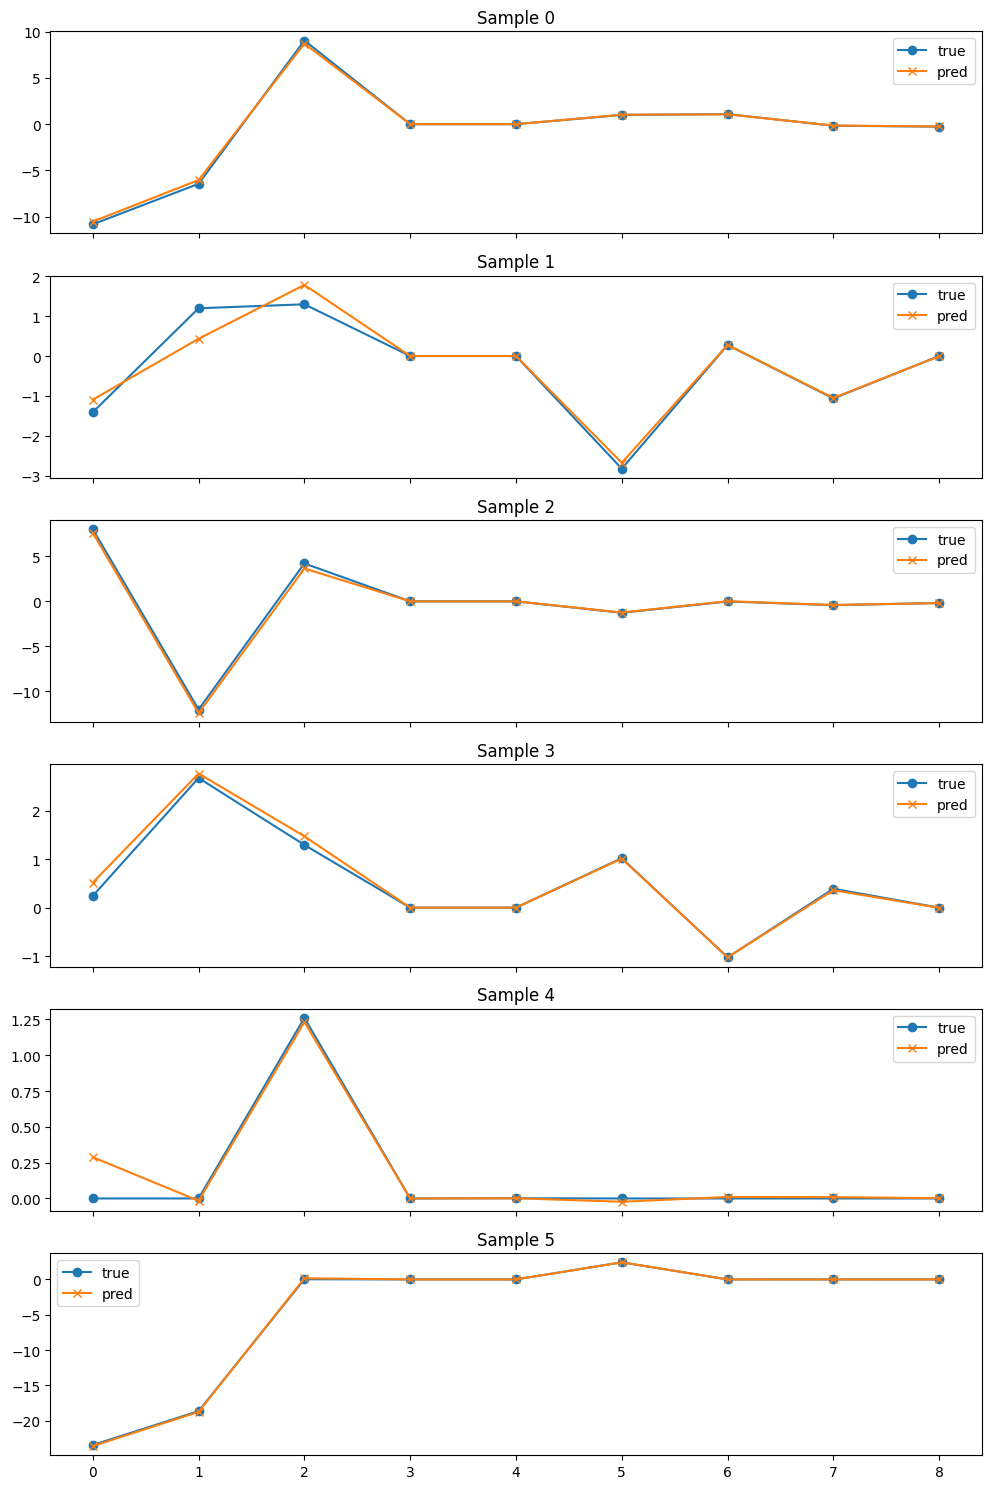

In [16]:
# Scatter global
plt.figure(figsize=(6,6))
plt.scatter(trues_phys.flatten(), preds_phys.flatten(), s=6, alpha=0.3)
mn = min(trues_phys.min(), preds_phys.min())
mx = max(trues_phys.max(), preds_phys.max())
plt.plot([mn,mx],[mn,mx],'r--')
plt.xlabel('Vérité')
plt.ylabel('Prédiction')
plt.title('Pred vs True (all dims)')
plt.grid(True)
plt.show()

# Quelques séries temporelles (Y_next) - affiche N exemples
Nplot = 6
idxs = np.arange(min(Nplot, preds_phys.shape[0]))
fig, axes = plt.subplots(Nplot, 1, figsize=(10, 2.5*Nplot), sharex=True)
for i, idx in enumerate(idxs):
    axes[i].plot(trues_phys[idx], label='true', marker='o')
    axes[i].plot(preds_phys[idx], label='pred', marker='x')
    axes[i].set_title(f"Sample {idx}")
    axes[i].legend()
plt.tight_layout()
plt.show()


In [17]:
OUT_DIR = "./trained_lstm"
os.makedirs(OUT_DIR, exist_ok=True)

torch.save(model.state_dict(), os.path.join(OUT_DIR, "lstm_model.pth"))
joblib.dump(scaler_X, os.path.join(OUT_DIR, "scaler_X.pkl"))
joblib.dump(scaler_Y, os.path.join(OUT_DIR, "scaler_Y.pkl"))

print("Modèle et scalers sauvegardés dans", os.path.abspath(OUT_DIR))


Modèle et scalers sauvegardés dans C:\Users\Maten\trained_lstm


In [18]:

SAVE_DIR = "figures"
os.makedirs(SAVE_DIR, exist_ok=True)

# =============================
# 1) Loss curves
# =============================
plt.figure(figsize=(8,4))
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss (log scale)')
plt.legend()
plt.title('Loss curves')
plt.grid(True)

plt.savefig(os.path.join(SAVE_DIR, "loss_curves.png"),
            dpi=300, bbox_inches="tight")
plt.close()

# =============================
# 2) Scatter global
# =============================
plt.figure(figsize=(6,6))
plt.scatter(trues_phys.flatten(), preds_phys.flatten(), s=6, alpha=0.3)
mn = min(trues_phys.min(), preds_phys.min())
mx = max(trues_phys.max(), preds_phys.max())
plt.plot([mn, mx], [mn, mx], 'r--')
plt.xlabel('Vérité')
plt.ylabel('Prédiction')
plt.title('Pred vs True (all dims)')
plt.grid(True)

plt.savefig(os.path.join(SAVE_DIR, "scatter_pred_vs_true.png"),
            dpi=300, bbox_inches="tight")
plt.close()

# =============================
# 3) Séries temporelles
# =============================
Nplot = 6
idxs = np.arange(min(Nplot, preds_phys.shape[0]))
fig, axes = plt.subplots(Nplot, 1, figsize=(10, 2.5*Nplot), sharex=True)

for i, idx in enumerate(idxs):
    axes[i].plot(trues_phys[idx], label='true', marker='o')
    axes[i].plot(preds_phys[idx], label='pred', marker='x')
    axes[i].set_title(f"Sample {idx}")
    axes[i].legend()

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "time_series_samples.png"),
            dpi=300, bbox_inches="tight")
plt.close()

print(f"Tous les graphes ont été enregistrés dans : {os.path.abspath(SAVE_DIR)}")


Tous les graphes ont été enregistrés dans : C:\Users\Maten\figures
